In [1]:
import os, re
import numpy as np
import scanpy as sc
from os.path import join
import pandas as pd
import shutil

import sys
import scipy.io as sio
import paste as pst
import scipy.sparse as sps
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.metrics import adjusted_rand_score

In [3]:
def collect_ads(_dir):
    fds = os.listdir(_dir)
    ads = []
    for fd in fds:
        if fd.startswith("R"):
            continue
        fns = os.listdir(join(_dir, fd))
        adx = sc.read_h5ad(join(_dir, fd, fns[0]))
        adxh = sc.AnnData(np.zeros((adx.n_obs, 2)), obs=adx.obs, obsm={"spatial":adx.obsm['spatial']})
        ads.append(adxh)
    return ads

In [6]:
target_methods = [
    'CLUE',
    'StabMap',
    'SpaMosaic(non-spatial)',
    'UINMF',
    'scMoMaT',
    'SpaMosaic',
    'MIDAS',
    'Cobolt',
    'MultiVI'
]

data_dir = '../../data/processed/'
cluster_dir = '../../results/clusters/'
score_dir = '../../results/scores/'

In [7]:
ds = 'Lymph-S1-S2-S3'
filtered_methods = [m for m in target_methods if os.path.exists(join(cluster_dir, m, ds, 'df_cluster.csv'))]
df_clusters = []
for meth in filtered_methods:
    df_clusters.append(pd.read_csv(join(cluster_dir, meth, ds, 'df_cluster.csv'), index_col=0))


In [14]:
ads = collect_ads(join(data_dir, ds))

for i,adx in enumerate(ads):
    for meth, dfc in zip(filtered_methods, df_clusters):
        comm_idx = dfc.index.intersection(adx.obs_names)
        adx = adx[comm_idx].copy()
        adx.obs[f'{meth}_cluster'] = dfc.loc[comm_idx, 'cluster'].to_list()
        adx.obs[f'{meth}_cluster'] = adx.obs[f'{meth}_cluster'].astype("category")
        ads[i] = adx

/home/yanxh/anaconda3/envs/torch2.0/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/yanxh/anaconda3/envs/torch2.0/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/yanxh/anaconda3/envs/torch2.0/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


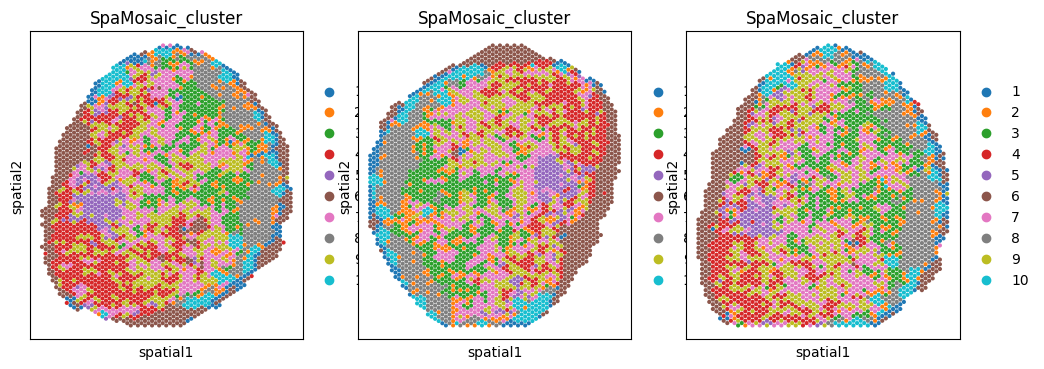

In [15]:
meth = 'SpaMosaic'

_, axes = plt.subplots(1, 3, figsize=(12, 4))
sc.pl.embedding(ads[0], basis='spatial', color=[f'{meth}_cluster'], ax=axes[0], show=False)
sc.pl.embedding(ads[1], basis='spatial', color=[f'{meth}_cluster'], ax=axes[1], show=False)
sc.pl.embedding(ads[2], basis='spatial', color=[f'{meth}_cluster'], ax=axes[2], show=False)
plt.show()